# 4-1 수업 내용
- AI Workflow란?
- Langchain이란?
- Langchain으로 구현하는 RAG
- Langchain으로 구현하는 AI Agent (다음주 진행 예정)

# 1. AI Workflow

- AI Workflow 라는 말 들어보셨을까요?
  - 코딩없이 자동화 프로그램을 만드는 "노코드" 프로그램들이 있습니다.
  - 아래 그림처럼 마우스로 배치하고, 연결하면 하나의 자동화프로그램이 완성됩니다.

<br/>

- 아래 그림을 보시면 됩니다.
  - 참고로 아래툴은 make 라는 툴입니다. (make.com)

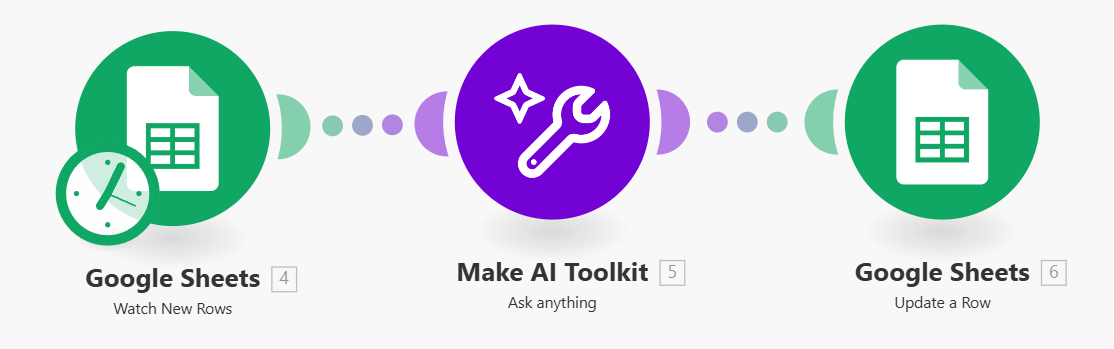

- 이렇게 동작됩니다.
  1. Google Sheet에 새로운 행이 생기면
  2. AI에게 데이터가 전달되고, 세팅된 프롬프트가 LLM에 자동 입력됩니다.
  3. LLM 이 만든 문장을 다시 Google Sheet에 적습니다.

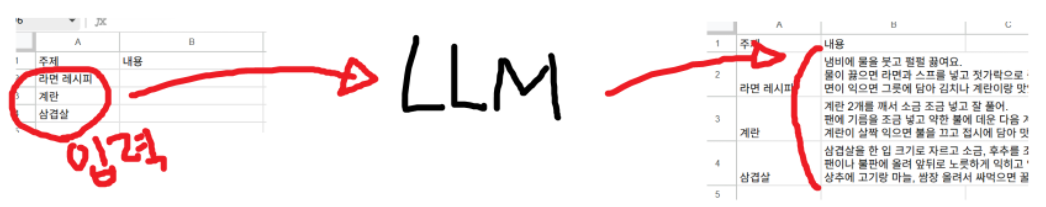

- 이렇게 동작이 되는 것이죠.
- 이렇게 입력 데이터가, 어디를 거치고, 또 어디를 거치고, AI도 거치고 하여, 출력을 내는 것 까지
- 이 데이터 처리 Flow를 만드는 것을 AI Workflow 라고 합니다.

<br/>

사무업무 자동화 툴로, 사무직 분들에게 인기가 많아요.
  - 반복적인 엑셀작업을 AI가 자동으로 초안을 작성하게 만들 수 있어요.
  - 영수증을 업로드하면 엑셀에 날짜, 시간, 가격 등 촥촥촥 정리되는 툴을 만들 수 있어요.
  - 긴급한 메일이 오면, AI가 내용을 요약하여 내 개인 SNS로 전송되게 만들 수 있어요.

<br/>

- 아래 그림은 다음과 같은 Workflow를 갖는것 같이 보여요.
  1. 뉴스에 신규 기사가 뜨자마자
  2. 내용을 요약하고
  3. 중요한 Text만 파싱하고
  4. 트위터, 페이스북에 전송하고,
  5. 관련 그림을 만들어서 링크드인에 이미지와 글을 올린다.

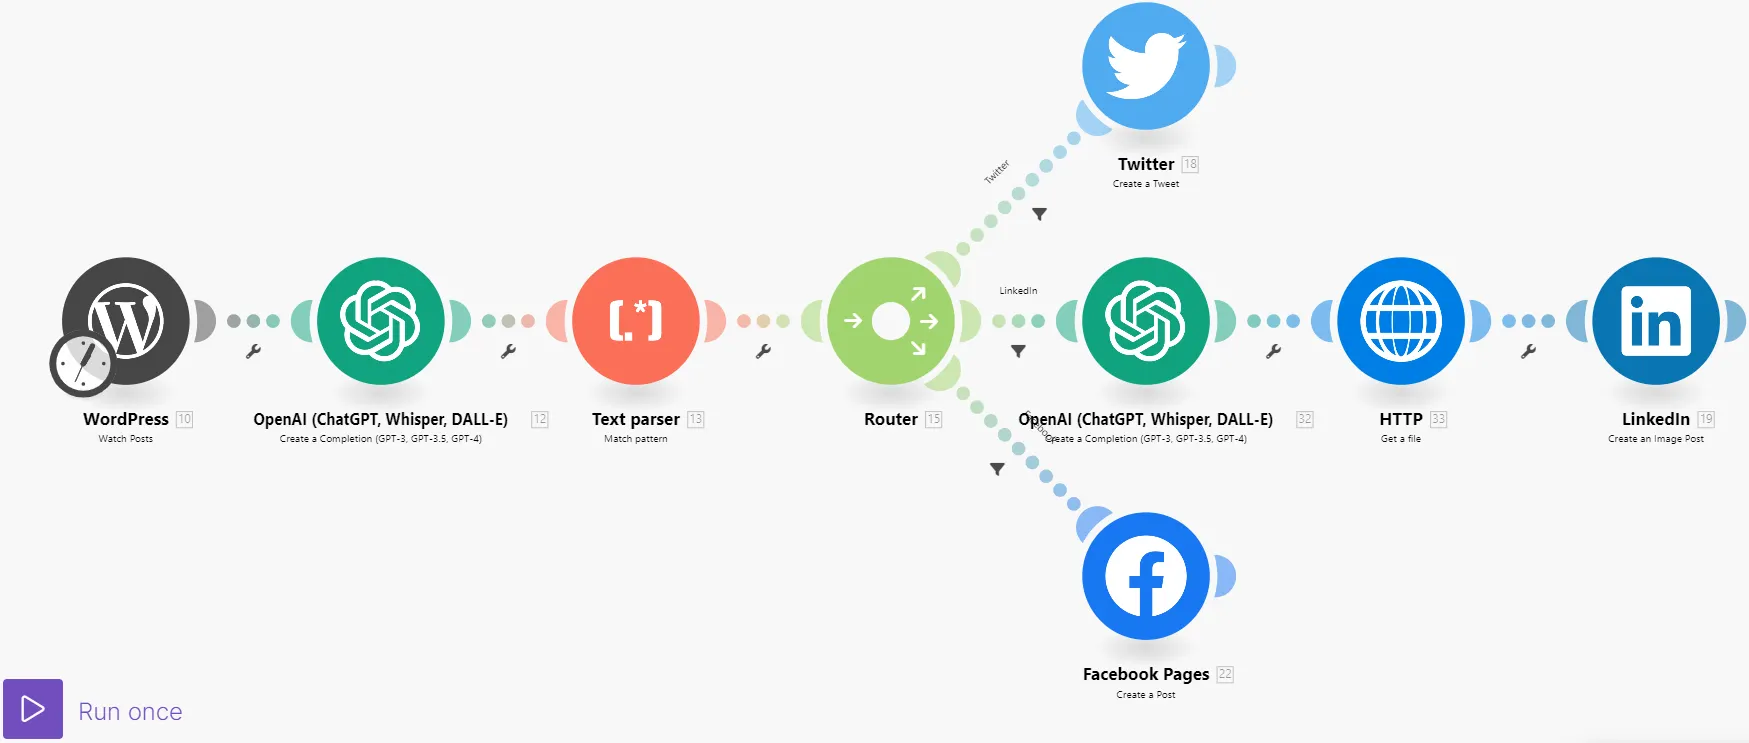

- AI Workflow가 무엇인지 이해하셨을 겁니다.

# 2. Langchain 은 무엇일까요?
- 노코드가 아니라, 코딩해서 만드는 AI Workflow 툴입니다.
- 우리의 첫 AI Workflow 제작을 위해 먼저 LLM 준비를 하겠습니다.


- 랭체인을 설치합시다.
  - langchain-openai 는 랭체인에서 openai를 사용할 수 있도록 만들어진 패키지입니다.

In [1]:
# 아래는 OpenAI Key를 사용할 때 설치할 라이브러리들
#!pip install langchain==0.3.28 langchain-openai==1.1.11

# 아래는 이번 예제에서 사용하는 라이브러리들
!pip install --upgrade \
  "langchain-core>=0.3.80,<0.4.0" \
  "langchain==0.3.28" \
  "langchain-community==0.3.28" \
  "langchain-openai==0.3.7" \
  "langchain-upstage==0.7.3" \
  "langchain-text-splitters==0.3.11" \
  "langchain-chroma==0.2.6" \
  "chromadb==1.5.5" \
  "transformers==4.46.0" \
  "tokenizers==0.20.3" \
  "huggingface-hub>=0.23.2,<1.0.0"

- 아래와 같이 AI Workflow를 갖는 코드를 작성해보겠습니다.
  - 1. Prompt : 프롬프트를 입력
  - 2. LLM : LLM이 프롬프트를 전달 받아 처리
  - 3. String : LLM 출력결과를 정리

- 각 단계를 Langchain에서는 **Component** 라고 합니다.

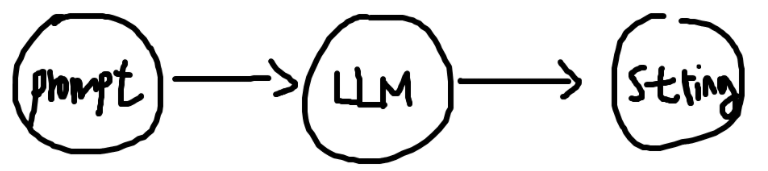

In [4]:
import os
import getpass

os.environ["UPSTAGE_API_KEY"] = getpass.getpass("Upstage API Key: ")

Upstage API Key:  ········


* langchain reference : https://reference.langchain.com/python/langchain-core/prompts/chat/ChatPromptTemplate
* upstage langchain doc : https://console.upstage.ai/docs/capabilities/generate/chat

In [3]:
# OpenAI의 모델을 불러오는 코드
#from langchain_openai import ChatOpenAI
#llm = ChatOpenAI(model="gpt-4o-mini", api_key=key)

from langchain_upstage import ChatUpstage # api로 업스테이지 AI모델 불러올때 사용하는 클래스
from langchain_core.prompts import ChatPromptTemplate # 프롬프트(질문 템플릿)를 만드는 도구
from langchain_core.output_parsers import StrOutputParser # LLM 응답을 깔끔한 문자열로 변환하는 outputparser() 이용할떄 사용하는 클래스

# Upstage 키 입력
key = os.getenv("UPSTAGE_API_KEY")

# Component 준비 (Workflow의 각 구성요소)
prompt = ChatPromptTemplate.from_template("넌 최고의 미식가야. 다음 질문에 대답해줘 <질문> : {input}")

# Upstage의 모델을 불러오는 코드
llm = ChatUpstage(model="solar-pro3", api_key=key)

output_parser = StrOutputParser() # content 부분만 출력하는 파서

# 체인 구성 (prompt --> llm --> output_parser), | : 파이프
chain = prompt | llm | output_parser

# 체인 수행!!
response = chain.invoke({"input": "가장 맛있는 햄버거 브랜드는? 10글자 내로 말해"})

print(response)


NameError: name 'os' is not defined

- 마우스를 드래그해서 연결했던 것과 동일하게 느껴집니다~.

# 4. ChatPromptTemplate 살펴보기
- 위 샘플코드에 있었던 ChatPromptTemplate 에 대해 살펴봅니다.

### OpenAI API 의 기본 입력 포맷


- OpenAI는 다음과 같은 포맷으로 입력을 받습니다.
```
[
  {
    "role": "system",
     "content": "너는 친절한 AI야."
  },
]
```
- 여기서 role에는 다음 내용을 넣습니다.
  - system : 모델의 역할을 지정합니다. (페르소나 or 행동지침)
    - 예시 : 넌 매우 밝고 친근한 맥도날드 점원이지
  - user : 사람이 입력한 질문 입니다.
    - 예시 : 가장 맛있는 버거 추천해줘
  - assistant : LLM이 생성한 응답입니다.
    - 예시 : 빅맥!
- OpenAI는 위와 같은 포맷을 사용합니다.

- 바로 ChatPromptTemplate 는 자동으로 system/user 형식의 메시지(JSON)을 만들어 주는 도우미 클래스 이빈다.

```
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 친절한 AI야."),
    ("user", "{input}")
])
```
위와 같이 정의하고 그리고 input에 안녕? 입력하면

   ```
    [
      {
        "role": "system",
        "content": "너는 친절한 AI야."
      },
      {
        "role": "user",
        "content": "안녕!"
      }
    ]
   ```
이러한 json 형식으로 변환해 주는 클래스 입니다.

### ChatPromptTemplate의 **from_template**
- LLM 에게 보낼 프롬프트를 만드는 서식(Template)입니다.
  - 기본 값으로 role="user"로 변환됩니다.
  - 단일 "user" 메시지를 템플릿으로 만드는 함수 입니다.




In [4]:
#from langchain_openai import ChatOpenAI
from langchain_upstage import ChatUpstage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

#openai
#key = userdata.get('OPEN_AI')

# Upstage 키 입력
key = os.getenv("UPSTAGE_API_KEY")

# Component 준비 (Workflow의 각 구성요소)
prompt = ChatPromptTemplate.from_template("내 달리기 속도는 {num1}m를 달리는데, {num2}초 걸려. 빠른 편이니?, 한 문장으로 이쁘게 말해봐")
llm = ChatUpstage(model="solar-pro3", api_key=key)
output_parser = StrOutputParser()

# 체인 구성 (prompt --> llm --> output_parser)
chain = prompt | llm | output_parser

# 체인 수행!!
response = chain.invoke({"num1" : 100, "num2" : 24})

print(response)

당신의 100m 달리기 기록은 24초로, 평균 이상의 속도로 꽤 빠른 편입니다. 🏃‍♀️💨


- 위 코드는 다음과 같은 JSON 형태 문자열이 됩니다.
```
[
  {
    "role": "user",
    "content": "내 달리기 속도는 {num1}m를 달리는데, {num2}초 걸려. 빠른 편이니?, 한 문장으로 이쁘게 말해봐"
  }
]
```

### ChatPromptTemplate의 **from_messages**
- ChatPromptTemplate은 OpenAI 가 사용하는 포맷에 맞게 템플릿을 변환해주는 역할을 합니다.
  - 여러 개의 역할(role: system, user, assistant 등)을 직접 정의해서 만드는 함수 입니다.
  - `.from_message` 네 넣을 값을 JSON을 직접 만들 필요 없습니다.
  - ("system", "..."), ("user", "...")처럼 튜플 형태로 간단히 입력하면,LangChain이 자동으로 LLM용 메시지 리스트로 바꿔줍니다.

  - Tuple 을 사용하면 코딩하기 편리하고 짧고 가독성이 좋아 가장 많이 사용합니다. (공식문서 예제 대부분 튜플사용)

In [5]:
#from langchain_openai import ChatOpenAI
from langchain_upstage import ChatUpstage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

#openai
#key = userdata.get('OPEN_AI')



# Upstage 키 입력
key = os.getenv("UPSTAGE_API_KEY")

# Component 준비 (Workflow의 각 구성요소)
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 무뚝뚝한 쉐프야. 항상 세줄 정도로 말하지."),
    ("user", "선생님, {food} 만드는 방법좀 알려주세요.")
])

#llm = ChatOpenAI(model="gpt-4o-mini", api_key=key)
llm = ChatUpstage(model="solar-pro3", api_key=key)

output_parser = StrOutputParser()

# 체인 구성 (prompt --> llm --> output_parser)
chain = prompt | llm | output_parser

# 체인 수행!!
response = chain.invoke({"food": "바베큐"})

print(response)


1. 고기를 양념에 2시간 재운다.  
2. 숯불에 직화로 굽고, 중간중간 뒤집어 고르게 익힌다.  
3. 구운 후 5분 정도 휴지시켜 육즙을 가두고, 먹기 전에 살짝 썰어 서빙한다.


- 위 코드는 다음과 같은 JSON 형태 문자열로 바뀌어 LLM에 입력됩니다.
```
[
    {
        "role": "system",
        "content": "너는 무뚝뚝한 쉐프야. 항상 세줄로 말하지."
    },
    {
        "role": "user",
        "content": "선생님, {food} 만드는 방법좀 알려주세요."
    }
]
```

#### ChatPromptTemplate의 from_template 와 from_messages 의 차이는 
#### 메시지를 1개 보내냐 or 메시지 여러 개 보내냐 차이 입니다.
```
prompt = ChatPromptTemplate.from_template(
    "질문: {question}"
)

prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 친절한 AI야"),
    ("user", "{question}")
])

```

### ChatPromptTemplate으로 Few-Shot 프롬프팅하기
- 몇 개의 예시를 주어, 예시 패턴에 따라 대답을 유도하는 프롬프팅을 Few-Shot 이라고 합니다.
  - 참고로 예시를 하나도 주지 않는 것을 Zero-Shot 이라고 하며, 앞에 예시코드는 Zero-Shot 이었죠.

In [7]:
#from langchain_openai import ChatOpenAI
from langchain_upstage import ChatUpstage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

#openai
#key = userdata.get('OPEN_AI')
# Upstage 키 입력
key = os.getenv("UPSTAGE_API_KEY")

# Component 준비 (Workflow의 각 구성요소)
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 무뚝뚝한 쉐프야. 항상 세줄로 말하지."),

    # Few-shot 1
    ("user", "선생님, 김치찌개 만드는 법 알려주세요."),
    ("assistant", "돼지고기, 김치많이, Last 두부"),

    # Few-shot 2
    ("user", "선생님, 계란말이 레시피 알려주세요."),
    ("assistant", "계란쫙, 간 조금, 천천히 Roll!"),

    ("user", "선생님, {food} 만드는 방법좀 알려주세요.")

])

#llm = ChatOpenAI(model="gpt-4o-mini", api_key=key)
llm = ChatUpstage(model="solar-pro3", api_key=key)
output_parser = StrOutputParser()

# 체인 구성 (prompt --> llm --> output_parser)
chain = prompt | llm | output_parser
#chain = prompt | llm  # LLM이 보내는 content + meta데이터(부가정보)까지 다 출력 ㅠㅠ

# 체인 수행!!
response = chain.invoke({"food": "보쌈"})

print(response)


돼지고기 삶고, 김치쌈, 고추가루 살짝.


# 5. RunnableLambda
- 내가 만든 함수를, Chain 안에 사용할 수있게해주는 컴포넌트입니다.
- RunnableLambda를 이용하면 여러 API들을 Custom하게 연동할 수 있겠죠?

In [17]:
#from langchain_openai import ChatOpenAI
from langchain_upstage import ChatUpstage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

#oepnai
#key = userdata.get('OPEN_AI')
#llm = ChatOpenAI(model="gpt-4o-mini", api_key=key)

# Upstage 키 입력
key = os.getenv("UPSTAGE_API_KEY")

# Component 준비
prompt = ChatPromptTemplate.from_template("항상 세 글자로 대답해 [질문] : {input}")
llm = ChatUpstage(model="solar-pro3", api_key=key)
output_parser = StrOutputParser()

# msg 파라메터: 이전 단계의 출력결과를 전달 받는 파라메터
def my_func(msg):
    
    if len(msg) == 3 :
        return msg
    return f'ERROR : "{msg}"는 세글자가 아닙니다.'

# 체인 구성 (prompt --> llm --> output_parser --> 함수)
chain = prompt | llm | output_parser | RunnableLambda(my_func)
#chain = prompt | llm | output_parser | my_func

# 체인 수행!!
response = chain.invoke({"input": "지금 너의 기분은?"})

print(response)


기뻐!


랭체인 공부하면 Runnable이라는게 계속 나올꺼에요.

- Runnable = “입력값을 받아서 어떤 처리를 한 뒤에, 출력값을 내보낼 수 있는 객체"를 러너블이라고 해요
- 쉽게이야기 하면, "실행 가능한 블록" 이라고 생각하시면 됩니다.

- 사실 `llm = ChatOpenAI()` 에서 ChatOpenAI도 하나의 Runnable 이구요
- StrOutputParser 도 문자열 파싱을 하나 하나의 Runnable 입니다.

- 그리고 뒤에 나오지만, Runnable 중에 이런것도 있어요. `RunnablePassthrough()`
  - 러너블패스트루는, 입력값을 받아서 어떤처리 안하고 그냥 바로 출력값을 내보낼 때 사용하는 러너블이라고 이해해 주시면 될것 같아요. 
  - LangChain의 파이프라인 구조에선 모든 단계가 실행이 가능객체여야 하거든요. (이를 Runnable 이라고함) 그래서 입력값에 어떠한 처리를 하고 싶지 않을때 RunnablePassthrough() 함수도 쓴답니다. :)

### 자~ 여기까지 Langchain에 대한 이해가 끝났습니다. 이제 Rag를 보죠

# 6. RAG (Retrieval Augmented Generation) 쉽게 이해하기!
- RAG는 기술 이름입니다~.
  - LLM에 사용자 질문과, 검색된 관련 정보를 함께 LLM에 넣어주는 기술입니다.
  - LLM이 더 똑똑하게 대답할수 있습니다.

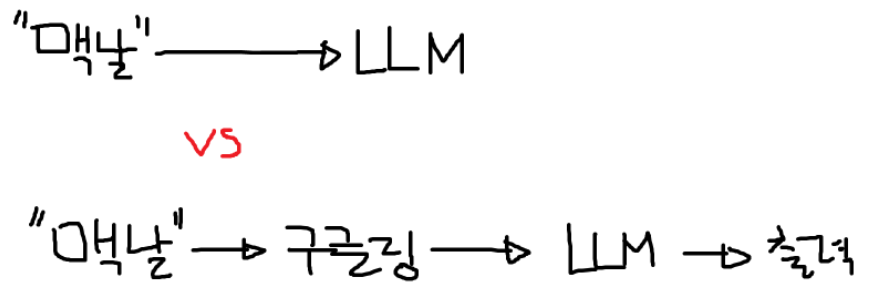

- 회사에서는 RAG를 필수적으로 사용합니다.
  - GPT는 회사만의 규율(사내규칙)을 모르거든요.
  - 그 회사만 가지고 있는 기술문서도 있을 것이구요.
  - 그래서 대기업에서는 사내용 LLM 시스템에 RAG를 사용하곤 합니다.
- 질문이 들어오면 사내문서를 검색한 내용을 LLM으로 출력할 문장을 만들어 출력합니다.
  

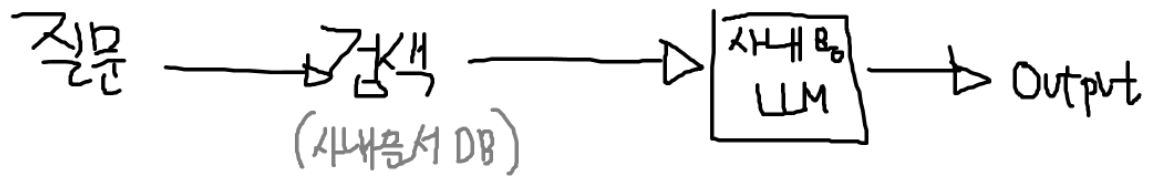

# 7. RAG 구현을 위한 준비!


- 먼저 사내문서들을 DB에 저장해두어야겠죠?
- 사내문서를 DB에 저장할때 두 가지 선택지가 있습니다.
  1. Text들을 그대로 DB에 저장해두기
      - 차후 검색시, 완벽히 동일한 단어 중심으로 검색을 하게 됩니다~!
      - 정확한 용어가 중요할 때에 사용하면 좋겠죠?

  2. Text들을 임베딩해서 Text의 의미벡터값을 저장해두기
      - 차후 검색시, 의미가 유사한 단어 중심으로 검색을 하게 됩니다~!
      - 정확한 단어를 입력하지 않아도 검색이 더 잘 되거나 유사한 많은 정보를 얻고 싶다면 이게 더 좋은 선택이 될 수 있을것 같아요.
<br/>

- RAG 기술을 구현할때는 둘 중 하나를 선택하면 됩니다!
  - 우리 실습에서는 임베딩해서, Text의 의미벡터값을 저장하겠습니다.

#### 실습 준비물 부터 챙겨 볼까요?



- 사내문서 Text를 그냥 DB에 저장하지 않고, 임베딩 벡터로 저장하겠습니다.
- 그러면 다음과 같은 준비물이 필요합니다.
  1. 사내문서 Text
  2. Text를 임베딩하여 의미공간의 벡터값으로 변경할 "임베딩 모델"
  3. 마지막으로 임베딩 값을 저장할 "DB"
  4. Cos 유사도가 높은 단어가 있는 문서를 검색해주는 "Retriever" Library

- 이렇게 4개만 우선 준비를 하면 됩니다. 엄청 많지는 않죠?

# 8. RAG 동작 과정 이해하기


- 아래 이미지를 보면 다음과 같은 과정으로 진행됩니다.
  - 준비 단계
    - 1. 사내 문서 Text로 추출하여, "Chunk" 라는 단락 단위로 나눕니다.
    - 2. "Chunk" 를 임베딩모델의 입력값으로 넣어, 벡터로 만들고 만듭니다.
    - 3. 벡터를 DB에 저장합니다.
  - Workflow 동작
    - 4. 질문 프롬프트를 입력 받습니다.
    - 5. 임베딩 모델을 거쳐 벡터 값을 얻어낸 후, Retriever로 유사한 Chunk를 검색합니다.
    - 6. 기존 질문과, 검색결과를 합쳐 프롬프트를 완성합니다. 
    - 7. 프롬프트를 LLM에 입력으로 넣습니다.
    - 8. 더 멋진 결과가 나옵니다.

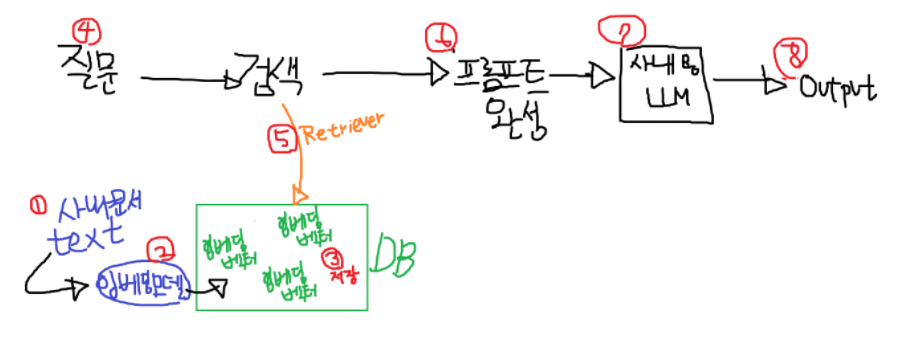

### RAG에 대한 Q&A
- Q. DB는 뭘 쓰나요?
- A. Vector 저장과 빠른 검색을 위한 Vector DB가 존재합니다. (Chroma, FAISS 등) <br/>
     그런데 그냥 MySQL을 써도 됩니다. MySQL 9.0 부터는 Vector도 지원되거든요.

<br/>

- Q. 왜 문서를 Chunk 단위로 쪼개나요?
- A. LLM이 거대한 문서 입력을 못받아들여서요.

<br/>

- Q. 문서 내용을 Chunk단위로 나눈다고 했는데, 몇 글자 정도로 나누나요?
- A. 보통 300 ~ 1000 토큰정도면 됩니다. 이정도면 LLM도 부담없고, 검색에 필요한 정보는 충분히 담길꺼예요. <br/>
   (한글 문장 수로 보면 한 20문장 정도)

<br/>

- Q. Chunk 단위로 자르면, 정보가 중간에 짤리는 것 아니예요?
- A. 네 맞습니다. 그래서 겹치는 구간(Overlap)을 두면서 Chunk로 자릅니다.

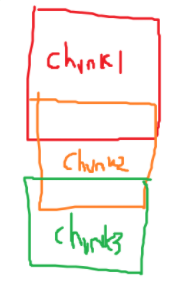

# 9. RAG 준비 단계

### Library 설치, 임베딩 모델을 위한 Upstage KEY 준비

- 실습에 필요한 Library를 먼저 설치합니다.
  - 임베딩모델은 한글 지역화가 잘되어있는 upstage 모델을 사용하겠습니다.
  - vector DB는 chromadb를 사용하겠습니다.

In [24]:
# 실습에 필요한 라이브러리들을 설치합니다.
!pip install -q langchain langchain-upstage langchain-community chromadb 

- 패키지들을 설치합니다.
  - langchain-upstage는 랭체인에서 업스테이지 llm을 쓸 수 있게 만들어진 어댑터 Library 입니다.
    - 이걸 설치하고 버전 충돌 에러메세지가 나온다면 무시해도 됩니다.
      - 아래 명령어를 수행하면, 기존 tokenizers 를 삭제하고, 낮은 버전의 tokenizers를 설치하게 됩니다.
      - 그러면 기존 transformer library 버전과 안맞다고 에러가 나는데, 무시해도 괜찮습니다.
  - langchain_community
    - 랭체인에서 자주사용되는 모듈들이 있습니다.
    - Text 파일을 불러오는데 사용되는 Loader, Vector DB와 연동해주는 모듈 등이 있습니다.
  - chromadb
    - 실습에 사용할 Vector DB 입니다.
    - vector값들을 저장하고, vector값을 검색해주는 검색기를 제공합니다.

### Text 준비하기

- 아래 코드를 수행하면, shipping_policy.txt 파일로 저장됩니다.
  

In [25]:
# Python 코드 활용
content = """
========================
AI 온라인 서점 배송 정책
========================
[일반 배송]
평일 오후 3시 이전 주문 시 당일 발송됩니다.
오후 3시 이후 주문 건은 익일 발송됩니다.
주말 및 공휴일은 배송이 어렵습니다.
도서 산간 지역 배송
제주 및 도서 산간 지역은 추가 배송비 3,000원이 발생할 수 있습니다.

[배송 조회]
배송 관련 문의는 고객센터(1588-0000)로 연락 주시기 바랍니다.

==============
배송 파손 정책
==============
상품이 배송 중 파손된 경우, 즉시 새 상품으로 교환해드립니다.
제품 이상이 확인되면 왕복 배송비는 전액 당사 부담입니다.
수령 후 7일 이내에 고객센터로 연락해 주셔야 합니다.
파손된 상품과 포장 상태 사진을 함께 제출해 주세요.
확인 후, 새 상품을 발송하거나 환불 절차를 진행합니다.
단순 변심이나 부주의로 인한 손상은 교환 대상이 아닙니다.
"""

with open("shipping_policy.txt", "w", encoding="utf-8") as f:
    f.write(content)

print("파일 생성 완료")


파일 생성 완료


- 폴더 이미지를 클릭해 문서가 만들어 진 것을 확인합니다.

# 문서를 Chunk 단위로 분할하기

- 다음 코드를 수행하여 Chunk 단위로 분할합니다.

In [26]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. Load: 텍스트 파일 불러오기
loader = TextLoader("./shipping_policy.txt") # 객체로 저장
documents = loader.load()                    # 저장된 객체의 실제 내용 저장
print("--- 원본 문서 ---")
# print(documents)
# print(documents[0].page_content)


# 2. Split: 문서를 200자 단위로 자르기 (엔터 단위, 40자씩 겹치게)
text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=40)
chunks = text_splitter.split_documents(documents)

print("\n--- 200자 단위로 잘린 문서 조각(Chunk)들 ---")
for i, chunk in enumerate(chunks):
    print(f"[Chunk {i+1}]")
    print(chunk.page_content)
    print()
    print()

--- 원본 문서 ---

--- 200자 단위로 잘린 문서 조각(Chunk)들 ---
[Chunk 1]
AI 온라인 서점 배송 정책
[일반 배송]
평일 오후 3시 이전 주문 시 당일 발송됩니다.
오후 3시 이후 주문 건은 익일 발송됩니다.
주말 및 공휴일은 배송이 어렵습니다.
도서 산간 지역 배송


[Chunk 2]
주말 및 공휴일은 배송이 어렵습니다.
도서 산간 지역 배송
제주 및 도서 산간 지역은 추가 배송비 3,000원이 발생할 수 있습니다.


[Chunk 3]
[배송 조회]
배송 관련 문의는 고객센터(1588-0000)로 연락 주시기 바랍니다.


[Chunk 4]
배송 파손 정책
상품이 배송 중 파손된 경우, 즉시 새 상품으로 교환해드립니다.
제품 이상이 확인되면 왕복 배송비는 전액 당사 부담입니다.
수령 후 7일 이내에 고객센터로 연락해 주셔야 합니다.
파손된 상품과 포장 상태 사진을 함께 제출해 주세요.


[Chunk 5]
파손된 상품과 포장 상태 사진을 함께 제출해 주세요.
확인 후, 새 상품을 발송하거나 환불 절차를 진행합니다.
단순 변심이나 부주의로 인한 손상은 교환 대상이 아닙니다.




* chunk_size=200
→ 텍스트를 최대 200자 단위로 쪼갠다는 뜻
(너무 길면 모델 입력 한도를 초과할 수 있고, 검색 효율도 떨어지기 때문에 잘라줌)

* chunk_overlap=40
→ 잘린 조각들 사이에 40자 겹치는 부분을 유지
(문맥이 끊기지 않게 하기 위함. 예: 문단 중간에서 끊겼을 때 앞뒤 연결 보장)

* Recursive
→ 문단 → 문장 → 단어 순으로 가능한 "큰 단위부터" 쪼개고, 그래도 너무 길면 더 작은 단위로 쪼갬.
(예: 그냥 문자 단위로 무조건 잘라내면 문장이 끊어져 이해가 어렵지만, Recursive는 문맥 단위를 최대한 지켜줌)

### Chunk를 임베딩 벡터로 변환 후 Vector DB에 저장하기
  - vector DB는 chromaDB를 사용합니다.
    - chromaDB는 내부적으로 SQLite 기반으로 구현되어있습니다.
    - 아래 코드를 수행하면 "./chroma_store"라는 폴더가 생성됩니다. 이곳에 저장됩니다.
  - 임베딩 모델은 Upstage 모델을 사용합니다.
  - https://console.upstage.ai/docs/capabilities/embed

In [27]:
from langchain_community.vectorstores import Chroma
from langchain_upstage import UpstageEmbeddings

# 텍스트를 숫자 벡터로 변환해주는 '임베딩 모델'을 준비합니다.
embeddings = UpstageEmbeddings(model="embedding-query", api_key=os.environ["UPSTAGE_API_KEY"])

# 잘라낸 문서 조각(chunks)들을 임베딩하여 Vector DB에 저장합니다.
vector_store = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory="./chroma_store")

print("Chunk들을 Vector DB에 저장 완료")

Chunk들을 Vector DB에 저장 완료


### 검색기(Retriever) 테스트
- chromaDB는 retriever도 제공합니다.
- Vector Store 객체가 질문과 관련된 정보를 잘 찾아주는지 테스트해볼까요?

In [28]:

# vector_store : 문서들을 벡터로 변환해 저장해둔 벡터DB
# .as_retriever() : 벡터DB를 검색용 객체로 변환
retriever = vector_store.as_retriever()

question = "주말에도 배송해주나요?"

# retriever.invoke(질문) 을 실행하면, 질문과 가장 관련 높은 문서 조각을 찾아줍니다.
retrieved_docs = retriever.invoke(question)

print(f"[질문]: {question}")
print(f"\n[검색 결과]:\n{retrieved_docs[0].page_content}")

[질문]: 주말에도 배송해주나요?

[검색 결과]:
주말 및 공휴일은 배송이 어렵습니다.
도서 산간 지역 배송
제주 및 도서 산간 지역은 추가 배송비 3,000원이 발생할 수 있습니다.


# 10. RAG Workflow!


- 동작시켜봅시다.

In [29]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_upstage import ChatUpstage

# LLM 모델을 준비합니다.
llm = ChatUpstage(model="solar-pro3", api_key=os.environ["UPSTAGE_API_KEY"])

# LLM에게 어떤 역할을 할지 알려주는 프롬프트(지시서)를 만듭니다.
prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 AI 온라인 서점의 친절한 고객 서비스 담당자입니다. 주어진 정보를 바탕으로 사용자의 질문에 답변해주세요."),
    ("user", "[질문]: {question}\n\n[참고 정보]: {context}"),
])

# RAG 체인(Chain)을 만듭니다.
rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}  # 1-1. Retriever로 정보 검색 후, "context" 에 값을 채움
                                                               # 1-2. RunnablePassthrough()은 전달받은 입력값을 그대로 넣음 (그냥 question은 에러남)
                                                               # 체인의 컴포넌트는 runnable 해야 함
    | prompt                                                   # 2. 검색된 정보와 질문을 프롬프트에 삽입
    | llm                                                      # 3. 완성된 프롬프트를 LLM에 전달
    | StrOutputParser()                                        # 4. LLM의 답변을 문자열로 변환
)

print("RAG 체인 준비 완료!")


RAG 체인 준비 완료!


- `{"context": retriever, "question": RunnablePassthrough()}` 오잉? 못보던게 나왔죠?

- 이건 랭체인에서 RunnableMap 이라고 해요.
  - 딕셔너리 모양으로 Runnable들을 묶으면
  - 랭체인이 각 key마다 병렬로 실행한 다음 실행결과를 하나의 딕셔너리로 묶어줘요.

- 자 그럼 실행 흐름을 볼까요?
  1. 밑에 코드에서 rag_chain.invoke ("주말 배송에 대해 알려주세요.") 라고 했어요
  2. RunnableMap 맵이 실행이 되요.
    - ```
      {
        "context": retriever.invoke(input),
        "question": RunnablePassthrough().invoke(input)
      }
   
   - 그래서 아래와 같이 하나의 딕셔너리로 묶이죠.
     - RunnablePassthrough() 는 별 기능 없어요. 아무 가공안하고 입력을 다음단계로 넘겨저는 Runnable 이에요.
     - ```
          "context": "검색된 문서 내용들...",
          "question": "주말 배송에 대해 알려주세요."
        ```








In [30]:
# RAG 체인에 질문을 던져봅니다.
question1 = "주말 배송에 대해 알려주세요."
answer1 = rag_chain.invoke(question1)
print(f"[질문 1]: {question1}")
print(f"[답변 1]: {answer1}")

print("---")

question2 = "제주도로 보내면 배송비가 추가되나요?"
answer2 = rag_chain.invoke(question2)
print(f"[질문 2]: {question2}")
print(f"[답변 2]: {answer2}")

[질문 1]: 주말 배송에 대해 알려주세요.
[답변 1]: 주말 및 공휴일에는 배송이 진행되지 않습니다.  
도서 산간 지역(제주 포함)의 경우 추가 배송비 3,000원이 부과될 수 있습니다.  
일반 배송 기준으로 평일 오후 3시 이전에 주문하면 당일 발송되며, 오후 3시 이후 주문은 익일 발송됩니다.
---
[질문 2]: 제주도로 보내면 배송비가 추가되나요?
[답변 2]: 제주도로 배송 시 추가 배송비가 발생할 수 있습니다.  
일반 배송 정책과 별도로 도서·산간 지역(제주 포함)은 **3,000원**의 추가 배송비가 부과될 수 있습니다.  

추가로 궁금한 점이 있으면 언제든 알려 주세요!


## 정리
 - **RAG**: 외부 문서를 참고하여 LLM 답변의 **정확성**과 **신뢰성**을 높이는 기술입니다.
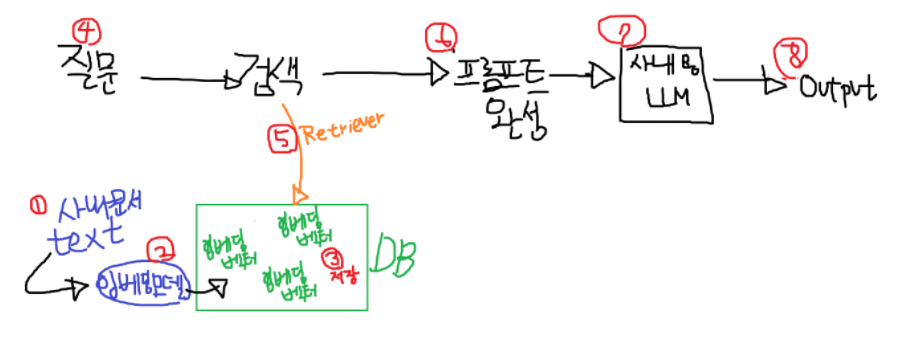
<br/>

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.
  